In [1]:
# Install imbalanced-learn (only needed once)
!pip install imbalanced-learn -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Generate a highly imbalanced dataset (90% Class 0, 10% Class 1)
X, y = make_classification(
    n_samples=1000,           # Total data points
    n_features=2,             # 2 features so we can visualize in 2D
    n_redundant=0,            # No redundant features
    n_clusters_per_class=1,   # One cluster per class
    weights=[0.90],           # 90% Class 0, 10% Class 1
    random_state=42           # Reproducibility
)

# Check the class distribution
print(f"Original class distribution: {Counter(y)}")
print(f"Class 0 (Majority): {Counter(y)[0]} samples")
print(f"Class 1 (Minority): {Counter(y)[1]} samples")

Original class distribution: Counter({np.int64(0): 896, np.int64(1): 104})
Class 0 (Majority): 896 samples
Class 1 (Minority): 104 samples


In [4]:
# Initialize SMOTE
smote = SMOTE(
    sampling_strategy='minority',  # Oversample until minority = majority count
    random_state=42,               # Reproducibility
    k_neighbors=5                  # Number of nearest neighbors to use
)

# Fit and resample the data
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the new distribution
print(f"Resampled class distribution: {Counter(y_resampled)}")
print(f"Class 0 (Majority): {Counter(y_resampled)[0]} samples")
print(f"Class 1 (Minority — now balanced): {Counter(y_resampled)[1]} samples")

Resampled class distribution: Counter({np.int64(0): 896, np.int64(1): 896})
Class 0 (Majority): 896 samples
Class 1 (Minority — now balanced): 896 samples


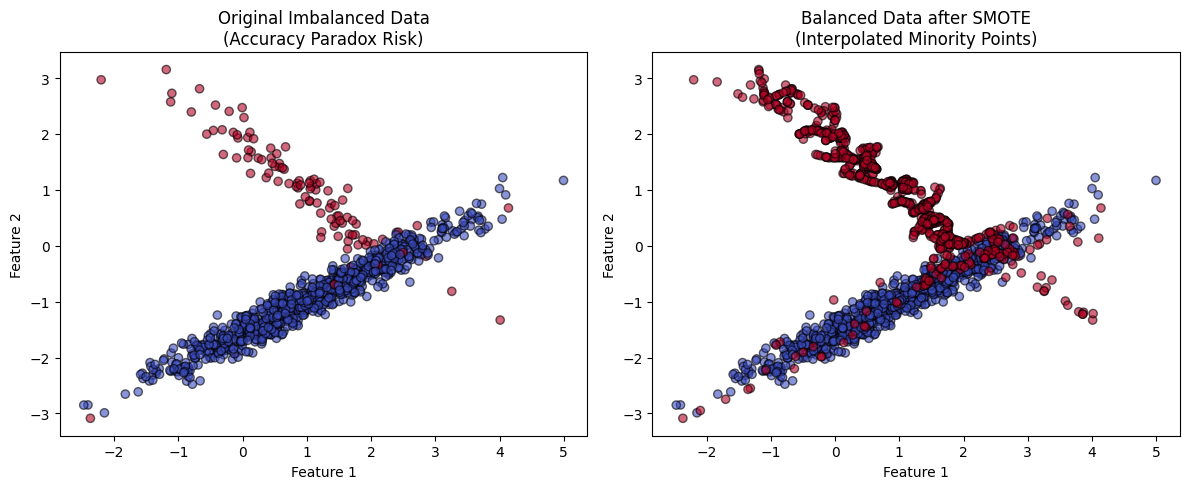


Observation: The right plot shows many more minority (blue) points — these are SMOTE-generated synthetic samples.


In [5]:
# Set up a side-by-side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Original Imbalanced Data ---
ax1.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6, cmap='coolwarm', edgecolors='k')
ax1.set_title("Original Imbalanced Data\n(Accuracy Paradox Risk)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

# --- Plot 2: Balanced Data after SMOTE ---
ax2.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, alpha=0.6,
            cmap='coolwarm', edgecolors='k')
ax2.set_title("Balanced Data after SMOTE\n(Interpolated Minority Points)")
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

print("\nObservation: The right plot shows many more minority (blue) points — these are SMOTE-generated synthetic samples.")